In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# بارگذاری دیتا
df = pd.read_csv('titanic.csv')

# نمایش اولیه
print("===== اطلاعات پایه =====")
print(f"تعداد مسافران: {len(df)}")
print(f"ستون‌ها: {list(df.columns)}")
print(f"مقادیر گمشده در سن: {df['Age'].isna().sum()}")
print()

===== اطلاعات پایه =====
تعداد مسافران: 891
ستون‌ها: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
مقادیر گمشده در سن: 177



In [3]:
# آمار کلی survival
survived = df['Survived'].value_counts()
print("===== بقا =====")
print(f"جان سالم به در بردند: {survived[1]} نفر ({survived[1]/len(df)*100:.1f}%)")
print(f"فوت کردند: {survived[0]} نفر ({survived[0]/len(df)*100:.1f}%)")
print()

# بقا بر اساس جنسیت
print("===== بقا بر اساس جنسیت =====")
sex_survival = df.groupby('Sex')['Survived'].mean() * 100
print(sex_survival.round(1))
print()

# بقا بر اساس کلاس
print("===== بقا بر اساس کلاس بلیط =====")
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print(class_survival.round(1))
print()

===== بقا =====
جان سالم به در بردند: 342 نفر (38.4%)
فوت کردند: 549 نفر (61.6%)

===== بقا بر اساس جنسیت =====
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

===== بقا بر اساس کلاس بلیط =====
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64



In [4]:
# آمار سن
print("===== آمار سن =====")
print(f"میانگین سن: {np.mean(df['Age'].dropna()):.1f}")
print(f"میانه سن: {np.median(df['Age'].dropna()):.1f}")
print(f"کمترین سن: {np.min(df['Age'].dropna())}")
print(f"بیشترین سن: {np.max(df['Age'].dropna())}")
print()

===== آمار سن =====
میانگین سن: 29.7
میانه سن: 28.0
کمترین سن: 0.42
بیشترین سن: 80.0



In [5]:
# رسم نمودارها
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

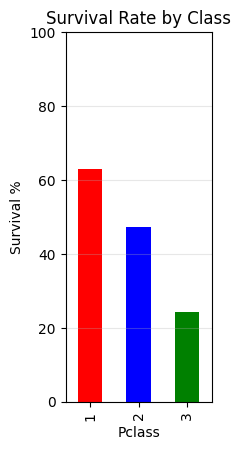

In [6]:
# نمودار 1: بقا بر اساس کلاس
plt.subplot(1, 3, 1)
class_survival.plot(kind='bar', color=['red', 'blue', 'green'])
plt.title('Survival Rate by Class')
plt.ylabel('Survival %')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

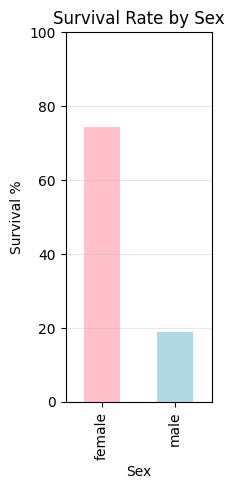

In [7]:
# نمودار 2: بقا بر اساس جنسیت
plt.subplot(1, 3, 2)
sex_survival.plot(kind='bar', color=['pink', 'lightblue'])
plt.title('Survival Rate by Sex')
plt.ylabel('Survival %')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

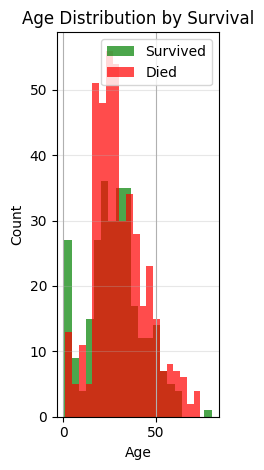

In [8]:
# نمودار 3: هیستوگرام سن برای فوت‌شده‌ها
plt.subplot(1, 3, 3)
df[df['Survived']==1]['Age'].dropna().hist(alpha=0.7, label='Survived', bins=20, color='green')
df[df['Survived']==0]['Age'].dropna().hist(alpha=0.7, label='Died', bins=20, color='red')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Survival')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()